### Import claims_data.csv and cust_data.csv which is provided to you and combine the two datasets appropriately to create a 360-degree view of the data. Use the same for the subsequent questions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
claims = pd.read_csv('claims.csv')
customer = pd.read_csv('cust_demographics.csv')

In [3]:
claims.head()

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent
0,54004764,21868593,Driver error,11/27/2017,Auto,No,Material only,$2980,1.0,No
1,33985796,75740424,Crime,10/03/2018,Home,Unknown,Material only,$2980,3.0,No
2,53522022,30308357,Other driver error,02/02/2018,Auto,No,Material only,$3369.5,1.0,Yes
3,13015401,47830476,Natural causes,06/17/2018,Auto,No,Material only,$1680,1.0,No
4,22890252,19269962,Crime,01/13/2018,Auto,No,Material only,$2680,1.0,No


In [4]:
customer.head() 

,CUST_ID,gender,DateOfBirth,State,Contact,Segment
0,21868593,Female,12-Jan-79,VT,789-916-8172,Platinum
1,75740424,Female,13-Jan-70,ME,265-543-1264,Silver
2,30308357,Female,11-Mar-84,TN,798-631-4758,Silver
3,47830476,Female,01-May-86,MA,413-187-7945,Silver
4,19269962,Male,13-May-77,NV,956-871-8691,Gold


In [6]:
combined360 = pd.merge(claims, customer, left_on='customer_id', right_on='CUST_ID', how='outer')

In [7]:
combined360.head()

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,CUST_ID,gender,DateOfBirth,State,Contact,Segment
0,54004764.0,21868593.0,Driver error,11/27/2017,Auto,No,Material only,$2980,1.0,No,21868593.0,Female,12-Jan-79,VT,789-916-8172,Platinum
1,33985796.0,75740424.0,Crime,10/03/2018,Home,Unknown,Material only,$2980,3.0,No,75740424.0,Female,13-Jan-70,ME,265-543-1264,Silver
2,53522022.0,30308357.0,Other driver error,02/02/2018,Auto,No,Material only,$3369.5,1.0,Yes,30308357.0,Female,11-Mar-84,TN,798-631-4758,Silver
3,63017412.0,30308357.0,Driver error,04/04/2018,Auto,No,Material only,$1950,6.0,No,30308357.0,Female,11-Mar-84,TN,798-631-4758,Silver
4,13015401.0,47830476.0,Natural causes,06/17/2018,Auto,No,Material only,$1680,1.0,No,47830476.0,Female,01-May-86,MA,413-187-7945,Silver


### Perform a data audit for the datatypes and find out if there are any mismatch within the current datatypes of the columns and their business significance.

In [8]:
combined360.dtypes

claim_id               float64
customer_id            float64
incident_cause          object
claim_date              object
claim_area              object
police_report           object
claim_type              object
claim_amount            object
total_policy_claims    float64
fraudulent              object
CUST_ID                float64
gender                  object
DateOfBirth             object
State                   object
Contact                 object
Segment                 object
dtype: object

### Convert claim_date and DateOfBirth to datetime

In [9]:
combined360['claim_date'] = pd.to_datetime(combined360['claim_date'], errors='coerce')

In [18]:
combined360['DateOfBirth'] = pd.to_datetime(combined360['DateOfBirth'], errors='coerce')

In [ ]:
claim_id               float64
customer_id            float64
total_policy_claims    float64


In [11]:
combined360.dtypes

claim_id                      float64
customer_id                   float64
incident_cause                 object
claim_date             datetime64[ns]
claim_area                     object
police_report                  object
claim_type                     object
claim_amount                   object
total_policy_claims           float64
fraudulent                     object
CUST_ID                       float64
gender                         object
DateOfBirth            datetime64[ns]
State                          object
Contact                        object
Segment                        object
dtype: object

### Convert the column claim_amount to numeric. Use the appropriate modules/attributes to remove the sign $.

In [12]:
combined360['claim_amount'] = combined360['claim_amount'].replace({'\$': '', ',': ''}, regex=True).astype(float)

In [13]:
# Check if 'customer_id' and 'CUST_ID' are identical
combined360['customer_id'].equals(combined360['CUST_ID'])

False

In [14]:
combined360.dtypes


claim_id                      float64
customer_id                   float64
incident_cause                 object
claim_date             datetime64[ns]
claim_area                     object
police_report                  object
claim_type                     object
claim_amount                  float64
total_policy_claims           float64
fraudulent                     object
CUST_ID                       float64
gender                         object
DateOfBirth            datetime64[ns]
State                          object
Contact                        object
Segment                        object
dtype: object

In [15]:
# Check for missing values
combined360.isnull().sum()

claim_id                7
customer_id             7
incident_cause          7
claim_date              7
claim_area              7
police_report           7
claim_type              7
claim_amount           72
total_policy_claims    17
fraudulent              7
CUST_ID                15
gender                 15
DateOfBirth            15
State                  15
Contact                15
Segment                15
dtype: int64

In [30]:
combined360.shape

(1100, 17)

### Check for missing values and impute the missing values with an appropriate value. (mean for continuous and mode for categorical)

# Handling Missing Values  

In [22]:
# Fill missing values for claim_id, customer_id, incident_cause, claim_date, claim_area, police_report, claim_type, fraudulent
combined360[['incident_cause', 'claim_area', 'police_report', 'claim_type', 'fraudulent']] = combined360[['incident_cause', 'claim_area', 'police_report', 'claim_type', 'fraudulent']].fillna('Unknown')

# For claim_id and customer_id, these might be critical, so consider dropping rows with missing values
combined360.dropna(subset=['claim_id', 'customer_id'], inplace=True)

# Fill missing values for claim_amount with the mean
combined360['claim_amount'] = combined360['claim_amount'].replace({'\$': '', ',': ''}, regex=True).astype(float)
combined360['claim_amount'].fillna(combined360['claim_amount'].mean(), inplace=True)

# Fill missing values for total_policy_claims with 0
combined360['total_policy_claims'].fillna(0, inplace=True)

# Fill missing values for CUST_ID by copying customer_id if CUST_ID is NaN
combined360['CUST_ID'].fillna(combined360['customer_id'], inplace=True)

# Fill missing values for gender, State, Contact, and Segment with 'Unknown'
combined360[['gender', 'State', 'Contact', 'Segment']] = combined360[['gender', 'State', 'Contact', 'Segment']].fillna('Unknown')

# Convert 'DateOfBirth' to datetime and fill with minimum date if missing
combined360['DateOfBirth'] = pd.to_datetime(combined360['DateOfBirth'], errors='coerce')
combined360['DateOfBirth'].fillna(combined360['DateOfBirth'].min(), inplace=True)

In [23]:
# Recheck for any remaining missing values
combined360.isnull().sum()

claim_id               0
customer_id            0
incident_cause         0
claim_date             0
claim_area             0
police_report          0
claim_type             0
claim_amount           0
total_policy_claims    0
fraudulent             0
CUST_ID                0
gender                 0
DateOfBirth            0
State                  0
Contact                0
Segment                0
dtype: int64

### Of all the injury claims, some of them have gone unreported with the police. Create an alert flag (1,0) for all such claims.

In [25]:
# First, standardize the 'police_report' column to handle variations like 'No' and 'Unknown'
combined360['police_report'] = combined360['police_report'].str.lower()  # Convert to lowercase for uniformity

# Create a list of claim types that involve injury
injury_claims = ['injury only', 'material and injury']

# Create an alert flag for unreported injury claims (police report is 'no' or 'unknown')
combined360['alert_flag'] = combined360.apply(
    lambda x: 1 if (x['claim_type'].lower() in injury_claims and (x['police_report'] == 'no' or x['police_report'] == 'unknown')) else 0, axis=1
)

# Check the result
combined360[['claim_type', 'police_report', 'alert_flag']]

,claim_type,police_report,alert_flag
0,Material only,no,0
1,Material only,unknown,0
2,Material only,no,0
3,Material only,no,0
4,Material only,no,0
...,...,...,...
1095,Material only,no,0
1096,Material only,no,0
1097,Material and injury,no,1
1098,Material and injury,unknown,1


### One customer can claim for insurance more than once and in each claim, multiple categories of claims can be involved. However, customer ID should remain unique. Retain the most recent observation and delete any duplicated records in the data based on the customer ID column

In [28]:
# Sort by customer_id and claim_date in descending order to have the most recent claims at the top
combined360.sort_values(by=['customer_id', 'claim_date'], ascending=[True, False], inplace=True)

# Drop duplicates based on customer_id, keeping only the most recent claim (first occurrence after sorting)
combined360_unique = combined360.drop_duplicates(subset=['customer_id'], keep='first').reset_index(drop=True)

In [29]:
# Check the result
combined360_unique.head()

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,CUST_ID,gender,DateOfBirth,State,Contact,Segment,alert_flag
0,69348631.0,154557.0,Driver error,2018-04-10,Auto,no,Injury only,12442.125121,1.0,Yes,154557.0,Female,1978-05-23,DE,962-879-1238,Platinum,1
1,40953049.0,263204.0,Other causes,2018-04-04,Auto,no,Material and injury,39192.000000,1.0,Yes,263204.0,Male,2072-12-20,TX,173-892-6314,Silver,1
2,45780237.0,287476.0,Natural causes,2017-10-17,Auto,unknown,Material only,1621.500000,2.0,Yes,287476.0,Male,1988-07-28,FL,364-598-1549,Silver,0
3,89833962.0,441097.0,Other causes,2018-03-21,Auto,yes,Material and injury,37040.000000,1.0,No,441097.0,Male,2071-08-19,CA,187-348-8375,Gold,0
4,35782742.0,524545.0,Other driver error,2018-07-27,Auto,no,Injury only,35250.000000,3.0,No,524545.0,Female,1980-08-10,NC,798-862-5398,Gold,1


### Calculate the age of customers in years. Based on the age, categorize the customers according to the below criteria 

### Children < 18
### Youth 18-30
### Adult 30-60
### Senior > 60


In [31]:
from datetime import datetime

In [32]:
# Calculate the current date
current_date = datetime.now()

# Calculate age in years
combined360_unique['age'] = (current_date - combined360_unique['DateOfBirth']).dt.days // 365

In [33]:
# Categorize based on age
def age_category(age):
    if age < 18:
        return 'Children'
    elif 18 <= age < 30:
        return 'Youth'
    elif 30 <= age < 60:
        return 'Adult'
    else:
        return 'Senior'

In [34]:
# Apply the age_category function to create a new column 'age_category'
combined360_unique['age_category'] = combined360_unique['age'].apply(age_category)

In [35]:
combined360_unique[['DateOfBirth', 'age', 'age_category']].head()


,DateOfBirth,age,age_category
0,1978-05-23,46,Adult
1,2072-12-20,-49,Children
2,1988-07-28,36,Adult
3,2071-08-19,-47,Children
4,1980-08-10,44,Adult


### What is the average amount claimed by the customers from various segments?

In [36]:
# Group by Segment and calculate the average claim amount
average_claim_by_segment = combined360_unique.groupby('Segment')['claim_amount'].mean().reset_index()

In [37]:
# Rename columns for clarity
average_claim_by_segment.columns = ['Segment', 'Average_Claim_Amount']

# Display the result
average_claim_by_segment

,Segment,Average_Claim_Amount
0,Gold,12842.865910
1,Platinum,12369.178329
2,Silver,12263.036137
3,Unknown,10704.300000


### What is the total claim amount based on incident cause for all the claims that have been done at least 20 days prior to 1st of October, 2018.

In [39]:
from datetime import datetime, timedelta

In [40]:
# Define the cutoff date as 20 days prior to October 1, 2018
cutoff_date = datetime(2018, 10, 1) - timedelta(days=20)

In [41]:
# Filter claims made before the cutoff date
filtered_claims = combined360_unique[combined360_unique['claim_date'] < cutoff_date]

In [43]:
# Calculate total claim amount by incident cause
total_claim_by_cause = filtered_claims.groupby('incident_cause')['claim_amount'].sum().reset_index()

In [44]:
# Rename columns for clarity
total_claim_by_cause.columns = ['Incident_Cause', 'Total_Claim_Amount']

In [45]:
# Display the result
total_claim_by_cause

,Incident_Cause,Total_Claim_Amount
0,Crime,7.267926e+05
1,Driver error,3.344146e+06
2,Natural causes,1.315001e+06
3,Other causes,3.777389e+06
4,Other driver error,3.342369e+06


### How many adults from TX, DE and AK claimed insurance for driver related issues and causes? 

In [46]:
# Filter for adults in specific states and driver-related incident causes
adult_driver_claims = combined360_unique[
    (combined360_unique['age_category'] == 'Adult') &
    (combined360_unique['State'].isin(['TX', 'DE', 'AK'])) &
    (combined360_unique['incident_cause'].str.contains('driver', case=False, na=False))
]

# Count the number of rows that meet the criteria
num_adult_driver_claims = adult_driver_claims.shape[0]

# Display the result
num_adult_driver_claims

20

### Draw a pie chart between the aggregated value of claim amount based on gender and segment. Represent the claim amount as a percentage on the pie chart.

In [47]:
# Aggregate claim amount by gender and segment
claim_amount_by_gender_segment = combined360_unique.groupby(['gender', 'Segment'])['claim_amount'].sum()

# Convert the Series to a DataFrame for easier handling in plotting
claim_amount_by_gender_segment = claim_amount_by_gender_segment.reset_index()

([<matplotlib.patches.Wedge at 0x141d4c04210>,
 [Text(-1.0753650082250898, 0.23149535434874885, 'Female - Gold'),
  Text(-0.750425710411372, -0.8042768510616154, 'Female - Platinum'),
  Text(0.2531968666189139, -1.0704631459019802, 'Female - Silver'),
  Text(1.0541874662065576, -0.31414771381150997, 'Male - Gold'),
  Text(0.7622679979340967, 0.7930621030698315, 'Male - Platinum'),
  Text(-0.28068434459985103, 1.0635865261917115, 'Male - Silver'),
  Text(-0.8159181292654019, 0.73775172404817, 'Unknown - Unknown')],
 [Text(-0.5865627317591399, 0.12627019328113573, '15.5%'),
  Text(-0.4093231147698392, -0.4386964642154265, '17.4%'),
  Text(0.13810738179213483, -0.5838889886738073, '13.9%'),
  Text(0.5750113452035768, -0.1713532984426418, '19.5%'),
  Text(0.4157825443276891, 0.4325793289471808, '15.4%'),
  Text(-0.15310055159991873, 0.5801381051954789, '17.2%'),
  Text(-0.4450462523265828, 0.40241003129900177, '1.2%')])

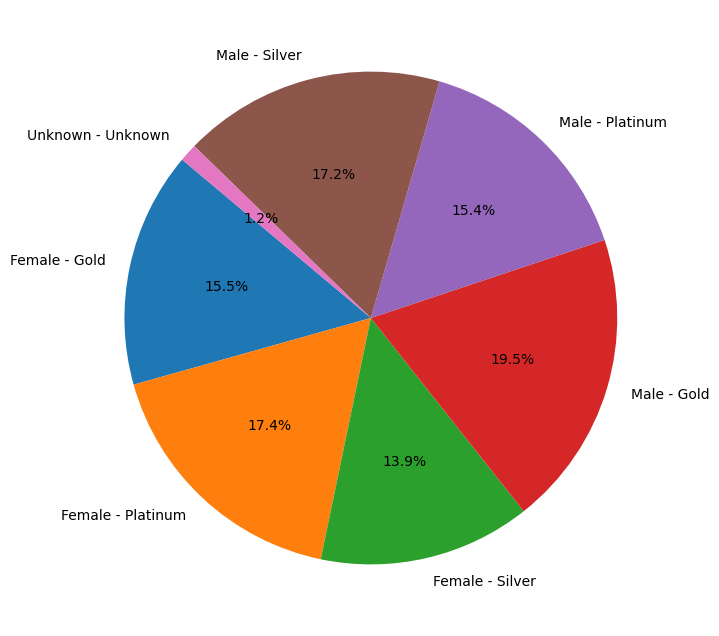

In [52]:
# Plotting the pie chart
plt.figure(figsize=(10, 8))
plt.pie(
    claim_amount_by_gender_segment['claim_amount'],
    labels=claim_amount_by_gender_segment.apply(lambda x: f"{x['gender']} - {x['Segment']}", axis=1),
    autopct='%1.1f%%',  # Show percentage on the chart
    startangle=140
)

### 2. Among males and females, which gender had claimed the most for any type of driver related issues? E.g. This metric can be compared using a bar chart

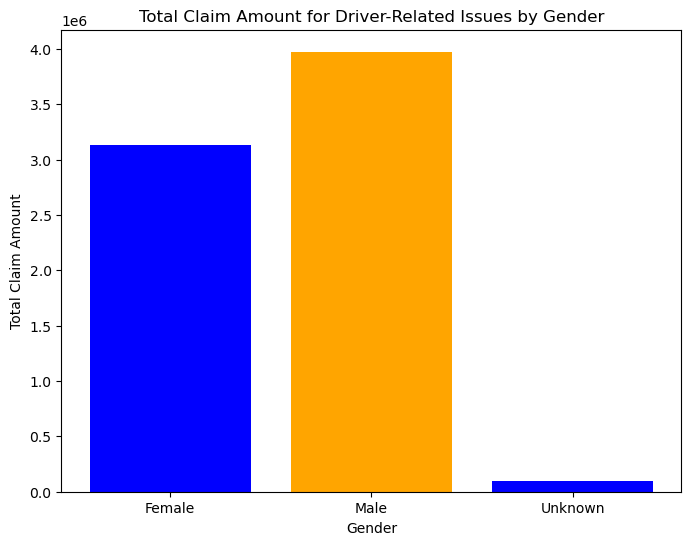

In [53]:
# Filter for driver-related incidents
driver_related_claims = combined360_unique[
    combined360_unique['incident_cause'].str.contains('driver', case=False, na=False)
]

# Aggregate claim amount by gender for driver-related incidents
claim_amount_by_gender = driver_related_claims.groupby('gender')['claim_amount'].sum().reset_index()

# Plotting the bar chart
plt.figure(figsize=(8, 6))
plt.bar(claim_amount_by_gender['gender'], claim_amount_by_gender['claim_amount'], color=['blue', 'orange'])

# Adding labels and title
plt.xlabel("Gender")
plt.ylabel("Total Claim Amount")
plt.title("Total Claim Amount for Driver-Related Issues by Gender")
plt.show()

###  Which age group had the maximum fraudulent policy claims? Visualize it on a bar chart.

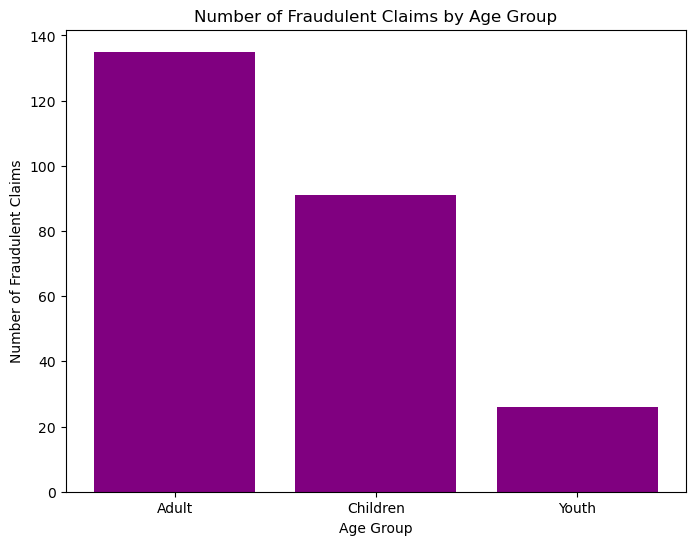

In [54]:

# Filter for fraudulent claims
fraudulent_claims = combined360_unique[combined360_unique['fraudulent'] == 'Yes']

# Count the number of fraudulent claims by age group
fraudulent_claims_by_age = fraudulent_claims.groupby('age_category').size().reset_index(name='fraudulent_claim_count')

# Plotting the bar chart
plt.figure(figsize=(8, 6))
plt.bar(fraudulent_claims_by_age['age_category'], fraudulent_claims_by_age['fraudulent_claim_count'], color='purple')

# Adding labels and title
plt.xlabel("Age Group")
plt.ylabel("Number of Fraudulent Claims")
plt.title("Number of Fraudulent Claims by Age Group")
plt.show()

### Visualize the monthly trend of the total amount that has been claimed by the customers. Ensure that on the “month” axis, the month is in a chronological order not alphabetical order. 

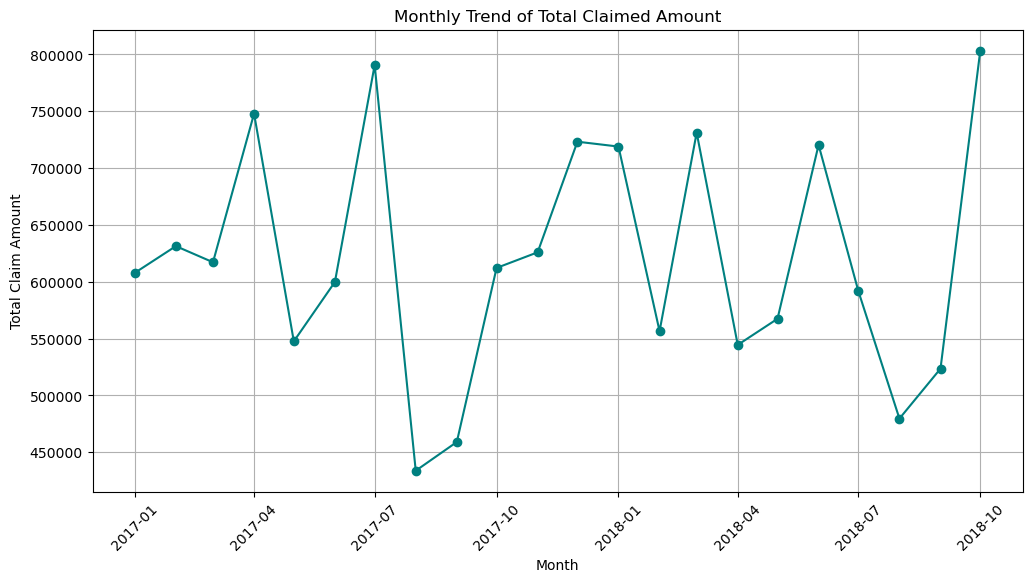

In [55]:
# Extract month and year from claim_date
combined360_unique['year_month'] = combined360_unique['claim_date'].dt.to_period('M')

# Group by year_month and sum up the claim amounts
monthly_claims = combined360_unique.groupby('year_month')['claim_amount'].sum().reset_index()

# Convert the `year_month` column back to datetime for sorting
monthly_claims['year_month'] = monthly_claims['year_month'].dt.to_timestamp()

# Plotting the line chart
plt.figure(figsize=(12, 6))
plt.plot(monthly_claims['year_month'], monthly_claims['claim_amount'], marker='o', color='teal')

# Adding labels and title
plt.xlabel("Month")
plt.ylabel("Total Claim Amount")
plt.title("Monthly Trend of Total Claimed Amount")
plt.xticks(rotation=45)
plt.grid()

plt.show()

### What is the average claim amount for gender and age categories and suitably represent the above using a facetted bar chart, one facet that represents fraudulent claims and the other for non-fraudulent claims.

<Figure size 1400x800 with 0 Axes>

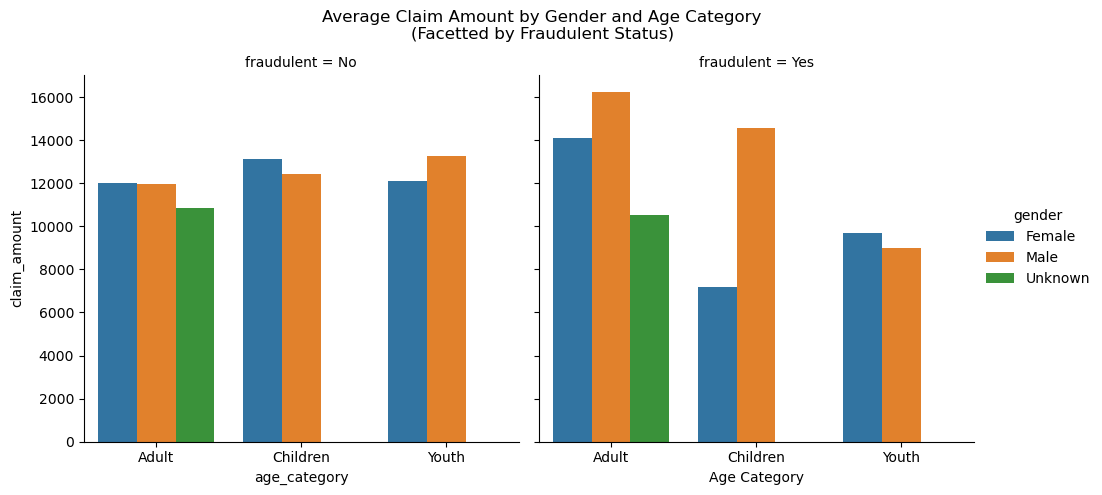

In [56]:
# Calculate average claim amount by gender, age category, and fraudulent status
avg_claim_by_gender_age_fraud = combined360_unique.groupby(['fraudulent', 'gender', 'age_category'])['claim_amount'].mean().reset_index()

# Plotting the facetted bar chart
plt.figure(figsize=(14, 8))
sns.catplot(
    data=avg_claim_by_gender_age_fraud, 
    x='age_category', 
    y='claim_amount', 
    hue='gender', 
    col='fraudulent', 
    kind='bar', 
    height=5, 
    aspect=1
)

# Adding titles and labels
plt.subplots_adjust(top=0.85)
plt.suptitle("Average Claim Amount by Gender and Age Category\n(Facetted by Fraudulent Status)")
plt.xlabel("Age Category")
plt.ylabel("Average Claim Amount")
plt.show()

# Statistical tests

### Is there any similarity in the amount claimed by males and females?

In [60]:
"""
Parameters Considered:

claim_amount (continuous variable)
gender (categorical variable with two levels: Male, Female)
Hypothesis:

Null Hypothesis (H0): There is no significant difference in the amount claimed between males and females. (i.e., mean claim amounts are similar)
Alternative Hypothesis (H1): There is a significant difference in the amount claimed between males and females.
Test Selection: Independent t-test, since we are comparing the means of two independent groups (males vs. females).

Testing Steps:

Check for normality using the Shapiro-Wilk test for claim_amount for each gender.
If data is normally distributed, proceed with the t-test; otherwise, use the non-parametric Mann-Whitney U test.
P-Value and Conclusion:

If the p-value is below the significance level (commonly 0.05), we reject the null hypothesis.
A significant result would indicate that there is a gender-based difference in the amount claimed.
Business Implication:

If a difference is found, this insight can help insurance companies tailor gender-specific strategies, potentially refining policies or claims processing approaches to address observed variations.

"""

'\nParameters Considered:\n\nclaim_amount (continuous variable)\ngender (categorical variable with two levels: Male, Female)\nHypothesis:\n\nNull Hypothesis (H0): There is no significant difference in the amount claimed between males and females. (i.e., mean claim amounts are similar)\nAlternative Hypothesis (H1): There is a significant difference in the amount claimed between males and females.\nTest Selection: Independent t-test, since we are comparing the means of two independent groups (males vs. females).\n\nTesting Steps:\n\nCheck for normality using the Shapiro-Wilk test for claim_amount for each gender.\nIf data is normally distributed, proceed with the t-test; otherwise, use the non-parametric Mann-Whitney U test.\nP-Value and Conclusion:\n\nIf the p-value is below the significance level (commonly 0.05), we reject the null hypothesis.\nA significant result would indicate that there is a gender-based difference in the amount claimed.\nBusiness Implication:\n\nIf a difference is

In [57]:
from scipy.stats import ttest_ind
# Dropping NaN values for claim_amount and filtering by gender
male_claims = combined360[combined360['gender'] == 'Male']['claim_amount'].dropna()
female_claims = combined360[combined360['gender'] == 'Female']['claim_amount'].dropna()

# Performing the t-test
t_stat, p_value = ttest_ind(male_claims, female_claims)

# Output results
print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 0.973500884403699
P-Value: 0.33052180166542333


###  Is there any relationship between age category and segment?

In [61]:
"""
Parameters Considered:

age_category (categorical variable with levels: Children, Youth, Adult, Senior)
segment (categorical variable with different segments such as Platinum, Gold, Silver, etc.)
Hypothesis:

Null Hypothesis (H0): There is no association between age category and segment.
Alternative Hypothesis (H1): There is an association between age category and segment.
Test Selection: Chi-square test of independence, as we are assessing the relationship between two categorical variables.

Testing Steps:

Create a contingency table of age_category vs. segment.
Apply the Chi-square test to see if the observed frequencies differ from expected frequencies.
P-Value and Conclusion:

If the p-value is less than 0.05, we conclude that there is a significant association between age category and segment.
A high p-value would indicate no significant association.
Business Implication:

An association may suggest targeted marketing opportunities. For example, if younger customers are more likely to be in a specific segment, tailored packages could be developed for those age groups to increase engagement.

"""

'\nParameters Considered:\n\nage_category (categorical variable with levels: Children, Youth, Adult, Senior)\nsegment (categorical variable with different segments such as Platinum, Gold, Silver, etc.)\nHypothesis:\n\nNull Hypothesis (H0): There is no association between age category and segment.\nAlternative Hypothesis (H1): There is an association between age category and segment.\nTest Selection: Chi-square test of independence, as we are assessing the relationship between two categorical variables.\n\nTesting Steps:\n\nCreate a contingency table of age_category vs. segment.\nApply the Chi-square test to see if the observed frequencies differ from expected frequencies.\nP-Value and Conclusion:\n\nIf the p-value is less than 0.05, we conclude that there is a significant association between age category and segment.\nA high p-value would indicate no significant association.\nBusiness Implication:\n\nAn association may suggest targeted marketing opportunities. For example, if younger c

In [65]:
from scipy.stats import chi2_contingency

In [66]:
combined360.head()

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,CUST_ID,gender,DateOfBirth,State,Contact,Segment,alert_flag
188,69348631.0,154557.0,Driver error,2018-04-10,Auto,no,Injury only,12442.125121,1.0,Yes,154557.0,Female,1978-05-23,DE,962-879-1238,Platinum,1
836,40953049.0,263204.0,Other causes,2018-04-04,Auto,no,Material and injury,39192.000000,1.0,Yes,263204.0,Male,2072-12-20,TX,173-892-6314,Silver,1
677,45780237.0,287476.0,Natural causes,2017-10-17,Auto,unknown,Material only,1621.500000,2.0,Yes,287476.0,Male,1988-07-28,FL,364-598-1549,Silver,0
828,89833962.0,441097.0,Other causes,2018-03-21,Auto,yes,Material and injury,37040.000000,1.0,No,441097.0,Male,2071-08-19,CA,187-348-8375,Gold,0
509,35782742.0,524545.0,Other driver error,2018-07-27,Auto,no,Injury only,35250.000000,3.0,No,524545.0,Female,1980-08-10,NC,798-862-5398,Gold,1


In [69]:
# Creating a contingency table
contingency_table = pd.crosstab(combined360_unique['age_category'], combined360_unique['Segment'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic:", chi2)
print("P-Value:", p)

Chi-Square Statistic: 14.774221275494046
P-Value: 0.022087358918137238


### The current year has shown a significant rise in claim amounts as compared to 2016-17 fiscal average which was $10,000.

In [70]:
"""
Parameters Considered:

claim_amount (continuous variable)
Benchmark average claim amount: $10,000
Hypothesis:

Null Hypothesis (H0): The current year’s average claim amount is $10,000 or less.
Alternative Hypothesis (H1): The current year’s average claim amount is greater than $10,000.
Test Selection: One-sample t-test to compare the current year’s mean claim amount to the benchmark of $10,000.

Testing Steps:

Calculate the mean claim amount for the current year.
Perform a one-sample t-test to compare this mean to $10,000.
P-Value and Conclusion:

A p-value below 0.05 would indicate a significant increase in the average claim amount compared to the benchmark.
Business Implication:

A significant rise in claims could indicate economic changes or emerging risks, prompting a review of underwriting policies, premium adjustments, or claims management strategies.

"""

'\nParameters Considered:\n\nclaim_amount (continuous variable)\nBenchmark average claim amount: $10,000\nHypothesis:\n\nNull Hypothesis (H0): The current year’s average claim amount is $10,000 or less.\nAlternative Hypothesis (H1): The current year’s average claim amount is greater than $10,000.\nTest Selection: One-sample t-test to compare the current year’s mean claim amount to the benchmark of $10,000.\n\nTesting Steps:\n\nCalculate the mean claim amount for the current year.\nPerform a one-sample t-test to compare this mean to $10,000.\nP-Value and Conclusion:\n\nA p-value below 0.05 would indicate a significant increase in the average claim amount compared to the benchmark.\nBusiness Implication:\n\nA significant rise in claims could indicate economic changes or emerging risks, prompting a review of underwriting policies, premium adjustments, or claims management strategies.\n\n'

In [72]:
# Filtering data for the current year
current_year_claims = combined360[combined360['claim_date'].dt.year == 2023]['claim_amount'].dropna()

In [73]:
# Performing one-sample t-test
from scipy.stats import ttest_1samp

In [74]:
t_stat, p_value = ttest_1samp(current_year_claims, 10000)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: nan
P-Value: nan


### Is there any difference between age groups and insurance claims?

In [76]:
"""
Parameters Considered:

claim_amount (continuous variable)
age_category (categorical variable with multiple levels)
Hypothesis:

Null Hypothesis (H0): There is no significant difference in the claim amounts across age groups.
Alternative Hypothesis (H1): There is a significant difference in claim amounts across age groups.
Test Selection: ANOVA (Analysis of Variance), as it compares means across more than two groups.

Testing Steps:

Group data by age_category.
Perform ANOVA to test if the means of claim_amount are significantly different across age groups.
P-Value and Conclusion:

A p-value below 0.05 indicates a significant difference in claim amounts across age groups, suggesting that age could be influencing claim behavior.
Business Implication:

If significant, insurers could explore age-specific claim trends to improve risk assessment models and pricing strategies, potentially creating age-appropriate packages to better meet customer needs.
"""

'\nParameters Considered:\n\nclaim_amount (continuous variable)\nage_category (categorical variable with multiple levels)\nHypothesis:\n\nNull Hypothesis (H0): There is no significant difference in the claim amounts across age groups.\nAlternative Hypothesis (H1): There is a significant difference in claim amounts across age groups.\nTest Selection: ANOVA (Analysis of Variance), as it compares means across more than two groups.\n\nTesting Steps:\n\nGroup data by age_category.\nPerform ANOVA to test if the means of claim_amount are significantly different across age groups.\nP-Value and Conclusion:\n\nA p-value below 0.05 indicates a significant difference in claim amounts across age groups, suggesting that age could be influencing claim behavior.\nBusiness Implication:\n\nIf significant, insurers could explore age-specific claim trends to improve risk assessment models and pricing strategies, potentially creating age-appropriate packages to better meet customer needs.\n'

In [77]:
from scipy.stats import f_oneway

In [81]:
# Splitting data by age categories and dropping NaN values for claim_amount
children_claims = combined360_unique[combined360_unique['age_category'] == 'Children']['claim_amount'].dropna()
youth_claims = combined360_unique[combined360_unique['age_category'] == 'Youth']['claim_amount'].dropna()
adult_claims = combined360_unique[combined360_unique['age_category'] == 'Adult']['claim_amount'].dropna()
senior_claims = combined360_unique[combined360_unique['age_category'] == 'Senior']['claim_amount'].dropna()

In [82]:
# Performing ANOVA
f_stat, p_value = f_oneway(children_claims, youth_claims, adult_claims, senior_claims)

print("F-Statistic:", f_stat)
print("P-Value:", p_value)

F-Statistic: nan
P-Value: nan


C:\Users\dssy1\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:4133: DegenerateDataWarning: at least one input has length 0
  warnings.warn(stats.DegenerateDataWarning('at least one input '


### . Is there any relationship between total number of policy claims and the claimed amount?

In [87]:
"""
Parameters Considered:

total_policy_claims (continuous variable, representing count)
claim_amount (continuous variable)
Hypothesis:

Null Hypothesis (H0): There is no correlation between the total number of policy claims and the claimed amount.
Alternative Hypothesis (H1): There is a significant correlation between the total number of policy claims and the claimed amount.
Test Selection: Pearson correlation coefficient to measure the linear relationship between total_policy_claims and claim_amount.

Testing Steps:

Calculate the Pearson correlation coefficient between total_policy_claims and claim_amount.
Determine if the correlation is statistically significant.
P-Value and Conclusion:

A p-value below 0.05 would indicate a significant correlation.
The strength and direction of the correlation can provide insights (e.g., a positive correlation would suggest that higher claim counts are associated with higher claim amounts).
Business Implication:

If correlated, the total number of claims could be used as an indicator for claim amount predictions. This insight can improve risk management strategies and enhance predictive models used in claims forecasting.

"""

'\nParameters Considered:\n\ntotal_policy_claims (continuous variable, representing count)\nclaim_amount (continuous variable)\nHypothesis:\n\nNull Hypothesis (H0): There is no correlation between the total number of policy claims and the claimed amount.\nAlternative Hypothesis (H1): There is a significant correlation between the total number of policy claims and the claimed amount.\nTest Selection: Pearson correlation coefficient to measure the linear relationship between total_policy_claims and claim_amount.\n\nTesting Steps:\n\nCalculate the Pearson correlation coefficient between total_policy_claims and claim_amount.\nDetermine if the correlation is statistically significant.\nP-Value and Conclusion:\n\nA p-value below 0.05 would indicate a significant correlation.\nThe strength and direction of the correlation can provide insights (e.g., a positive correlation would suggest that higher claim counts are associated with higher claim amounts).\nBusiness Implication:\n\nIf correlated,

In [88]:
from scipy.stats import pearsonr

In [89]:
# Dropping NaN values
total_claims = combined360_unique['total_policy_claims'].dropna()
claim_amount = combined360_unique['claim_amount'].dropna()

# Calculating Pearson correlation
correlation, p_value = pearsonr(total_claims, claim_amount)

print("Correlation Coefficient:", correlation)
print("P-Value:", p_value)

Correlation Coefficient: -0.025091033973821106
P-Value: 0.4072715352260574
